#Training a model for image classification

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory

import os
import matplotlib.image as mpimg

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [3]:
import os
import zipfile

local_zip = '../data/datasets_200.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('../data/')
zip_ref.close()

local_zip = '../data/datasets_1000.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('../data/')
zip_ref.close()

local_zip = '../data/datasets_2000.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('../data/')
zip_ref.close()

local_zip = '../data/datasets_8000.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('../data/')
zip_ref.close()

In [ ]:
# WARNING: This command will delete all files and directories in the current working directory.
# Use with extreme caution!
# You will be prompted to confirm before deletion.
# !rm -rf ./__MACOSX/
# !rm -rf ./sample_data/
# !rm datasets_200.zip
# !rm datasets_1000.zip
# !rm datasets_2000.zip
# !rm datasets_8000.zip

['./datasets_200/train/cats/cat.925.jpg', './datasets_200/train/cats/cat.926.jpg', './datasets_200/train/cats/cat.931.jpg', './datasets_200/train/cats/cat.970.jpg', './datasets_200/train/cats/cat.984.jpg', './datasets_200/train/cats/cat.954.jpg', './datasets_200/train/cats/cat.975.jpg', './datasets_200/train/cats/cat.903.jpg']


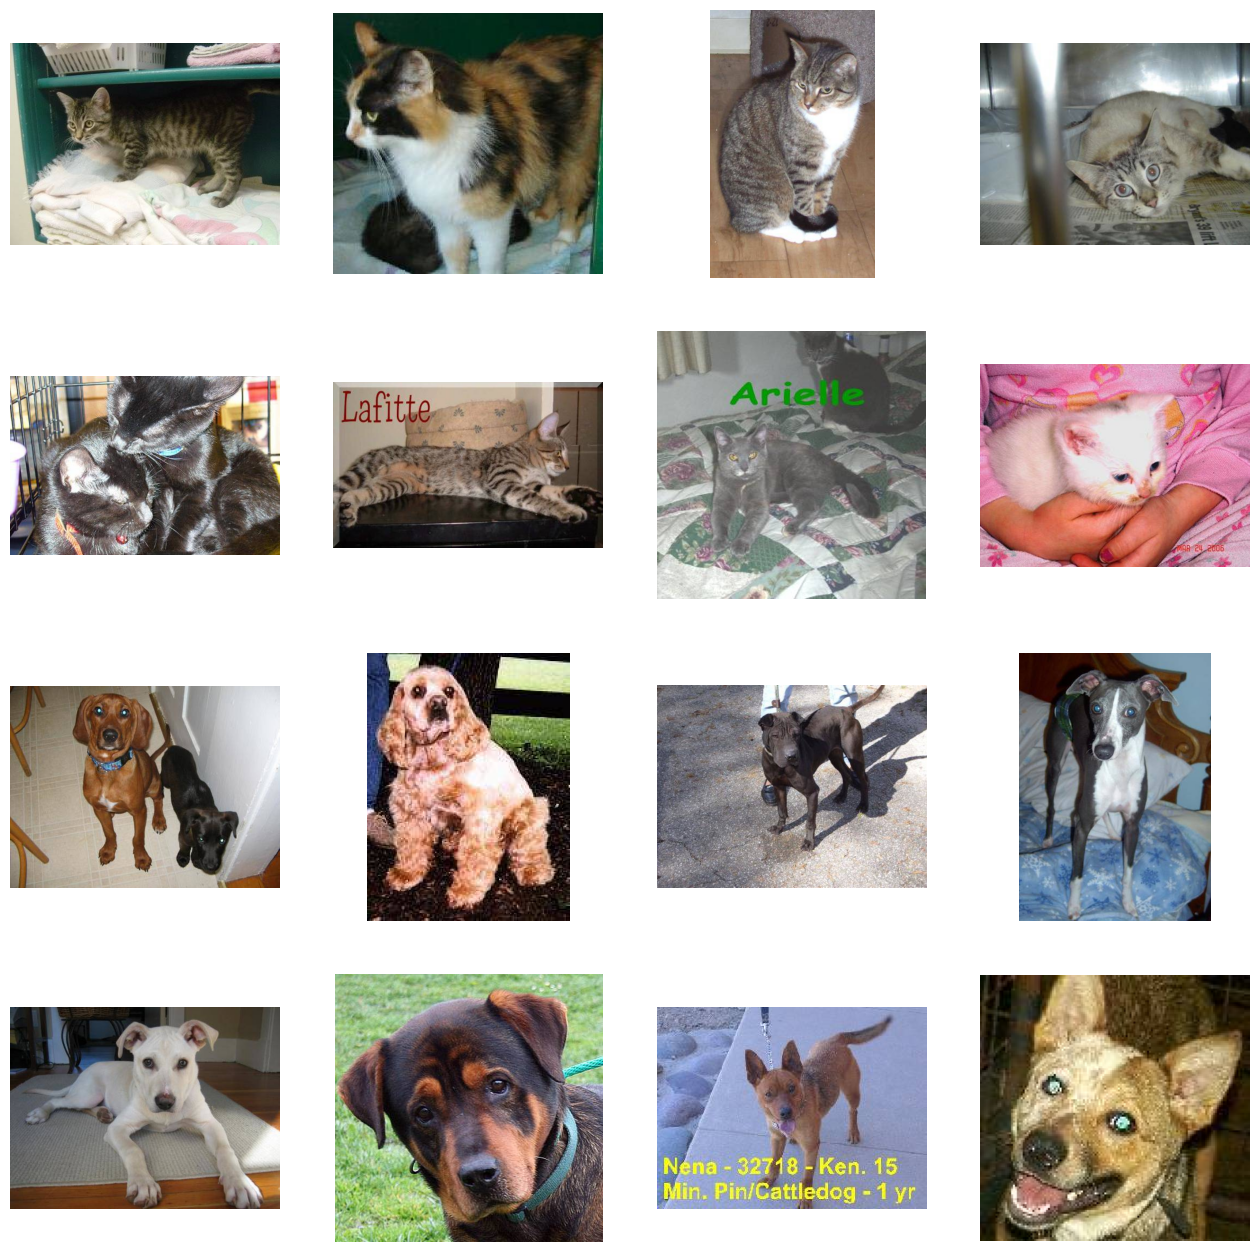

In [4]:
fig = plt.gcf()
fig.set_size_inches(16, 16)


cat_dir = '../data/datasets_200/train/cats'
dog_dir = '../data/datasets_200/train/dogs'

cat_names = os.listdir(cat_dir)
dog_names = os.listdir(dog_dir)

pic_index = 10

cat_images = [os.path.join(cat_dir, fname)
              for fname in cat_names[pic_index-8:pic_index]]
dog_images = [os.path.join(dog_dir, fname)
              for fname in dog_names[pic_index-8:pic_index]]


print(cat_images)

for i, img_path in enumerate(cat_images + dog_images):
    sp = plt.subplot(4, 4, i+1)
    sp.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [5]:
base_dir = '../data/datasets_200/train/'

train_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)
valid_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)

Found 200 files belonging to 2 classes.
Using 180 files for training.
Found 200 files belonging to 2 classes.
Using 20 files for validation.


In [6]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [13]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(valid_datagen,
          epochs=10,
          validation_data=valid_datagen)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.3000 - val_loss: 60.3211
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0382 - val_accuracy: 0.3000 - val_loss: 62.9499
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.3000 - val_loss: 61.7083
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.3000 - val_loss: 57.3686
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0313 - val_accuracy: 0.3000 - val_loss: 48.8579
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.3000 - val_loss: 43.3181
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 0.3000 - val_loss: 44.8272
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.3000 - val_loss: 47.5994
Epoch 9/

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred = model.predict(valid_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in valid_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
Number of predictions: 20
Number of true labels: 20


In [15]:
from sklearn.metrics import classification_report

# Print the classification report
print(classification_report(y_true, y_pred_classes, target_names=valid_datagen.class_names))

              precision    recall  f1-score   support

        cats       0.30      1.00      0.46         6
        dogs       0.00      0.00      0.00        14

    accuracy                           0.30        20
   macro avg       0.15      0.50      0.23        20
weighted avg       0.09      0.30      0.14        20



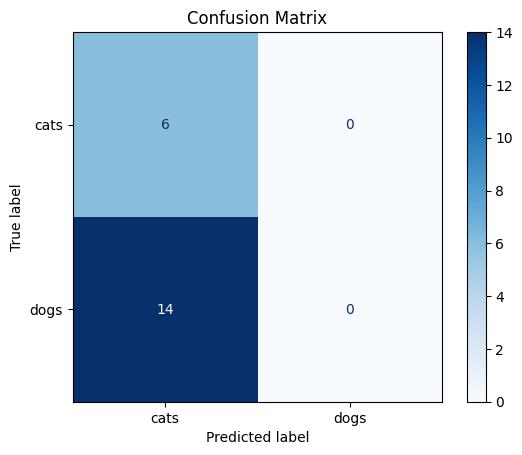

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = valid_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

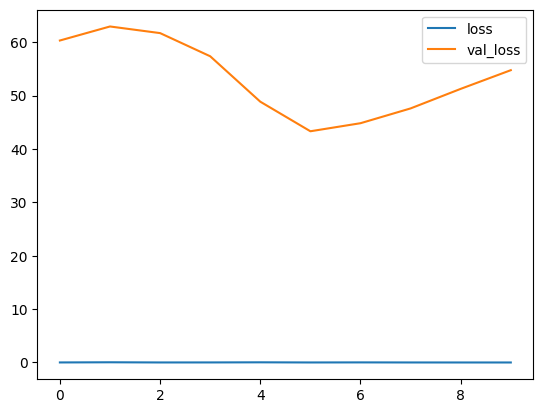

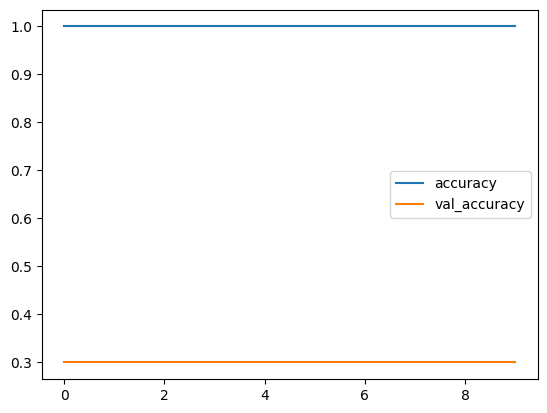

In [18]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Cat


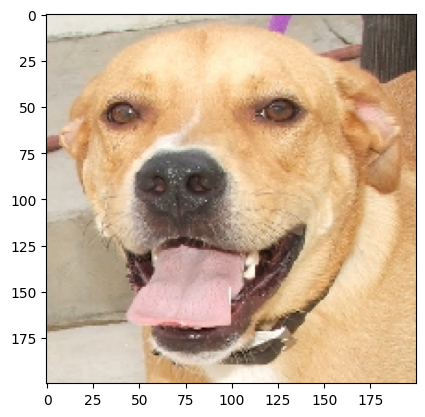

In [19]:
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = load_img(image_path, target_size=(200, 200))
    plt.imshow(img)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    result = model.predict(img)
    print("Dog" if result >= 0.5 else "Cat")

predict_image('../data/datasets_8000/train/dogs/2001.jpg')

#<font color='blue'>Increasing Dataset

In [ ]:
base_dir = '../data/datasets_2000/train/'

train_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                  validation_split=0.1,
                                                  batch_size= 32)
test_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                  validation_split=0.1,
                                                  batch_size= 32)
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(train_datagen,
          epochs=10,
          validation_data=test_datagen)

Found 2000 files belonging to 2 classes.
Using 1800 files for training.
Found 2000 files belonging to 2 classes.
Using 200 files for validation.
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.5157 - loss: 0.9652 - val_accuracy: 0.4800 - val_loss: 1.1774
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.5722 - loss: 0.7513 - val_accuracy: 0.5500 - val_loss: 2.6425
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6034 - loss: 0.7007 - val_accuracy: 0.5850 - val_loss: 0.7327
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.6175 - loss: 0.6769 - val_accuracy: 0.4650 - val_loss: 1.1421
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.6386 - loss: 0.6616 - val_accuracy: 0.5650 - val_loss: 0.6891
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.6528 - loss: 0.6520 - val_accuracy: 0.5500 - val_loss: 0.7997
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6287 - loss: 0.6679 - val_ac

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 923ms/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       0.45      0.85      0.58        91
        dogs       0.48      0.12      0.19       109

    accuracy                           0.45       200
   macro avg       0.46      0.48      0.39       200
weighted avg       0.46      0.45      0.37       200



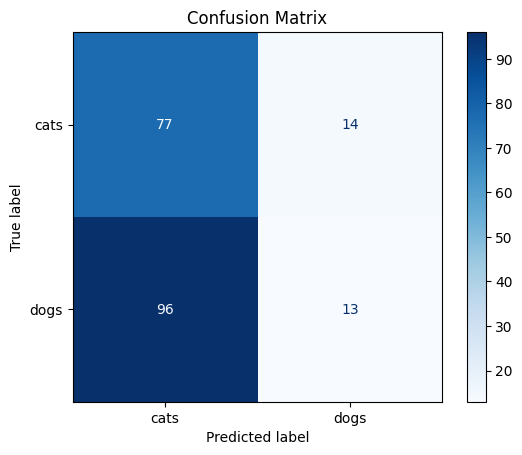

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [40]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt

# 1. การเตรียมข้อมูลด้วย Rescaling และ Data Augmentation
#    เนื่องจาก image_dataset_from_directory ไม่ปรับขนาด เราจึงต้องเพิ่ม Rescaling Layer
#    และเพิ่ม layers สำหรับ Data Augmentation
normalization_layer = Rescaling(1./255)
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

# Load data
base_dir = '../data/datasets_2000/train/'
train_datagen = image_dataset_from_directory(
    base_dir,
    image_size=(200, 200),
    subset='training',
    seed=1,
    validation_split=0.1,
    batch_size=32
)
test_datagen = image_dataset_from_directory(
    base_dir,
    image_size=(200, 200),
    subset='validation',
    seed=1,
    validation_split=0.1,
    batch_size=32
)

# 2. สร้างโมเดลใหม่ที่ใช้ Data Augmentation และ Dropout
model = Sequential()
model.add(data_augmentation) # เพิ่ม Data Augmentation ที่นี่
model.add(normalization_layer) # เพิ่ม Normalization Layer
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # เพิ่ม Dropout เพื่อป้องกัน Overfitting
model.add(Dense(1, activation='sigmoid'))

# 3. Compile และ Fit โมเดล
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    train_datagen,
    epochs=3, # เพิ่ม epochs
    validation_data=test_datagen
)

Found 2000 files belonging to 2 classes.
Using 1800 files for training.
Found 2000 files belonging to 2 classes.
Using 200 files for validation.
Epoch 1/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.5117 - loss: 0.7424 - val_accuracy: 0.5800 - val_loss: 0.6815
Epoch 2/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.5661 - loss: 0.6737 - val_accuracy: 0.5700 - val_loss: 0.7081
Epoch 3/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.6194 - loss: 0.6492 - val_accuracy: 0.7050 - val_loss: 0.5875


#<font color='blue'>Data Augmentation
Augment the cat and dog images using techniques like rotation, zooming, and flipping, then retrain the existing model with the augmented data and evaluate its performance.

## Define image augmentation

### Subtask:
Specify the augmentation techniques you want to apply (e.g., rotation, zooming, flipping).


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_augmented = ImageDataGenerator(
    rescale=1./255, # Add rescaling
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1 # Add validation split here
)

test_datagen_augmented = ImageDataGenerator(rescale=1./255, validation_split=0.1) # Add rescaling and validation split here

**Reasoning**:
Define the image augmentation techniques using `ImageDataGenerator`.



## Create augmented data generators

### Subtask:
Use `ImageDataGenerator` with the specified augmentation parameters for the training dataset. Keep the validation dataset without augmentation.


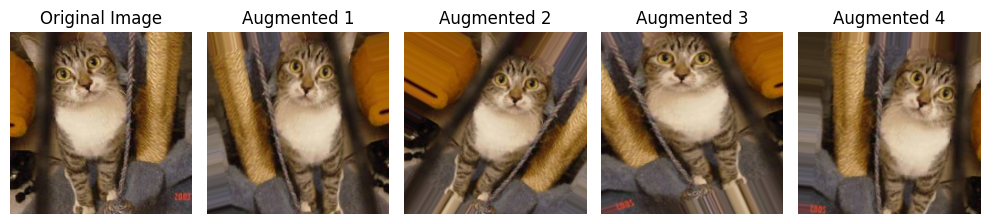

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# 1. Define ImageDataGenerator (หากยังไม่ได้ทำ)
train_datagen_augmented = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Load image
img_path = '../data/datasets_200/train/cats/cat.936.jpg'
img = load_img(img_path, target_size=(200, 200))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 3. Generate augmented images
augmented_images = train_datagen_augmented.flow(img_array, batch_size=1)

# 4. Plot original and augmented
plt.figure(figsize=(10, 10))
plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

for i in range(4):
    augmented_img = next(augmented_images)[0]
    augmented_img = np.clip(augmented_img, 0, 255).astype('uint8')
    plt.subplot(1, 5, i+2)
    plt.imshow(augmented_img)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Create augmented data generators

### Subtask:
Use `ImageDataGenerator` with the specified augmentation parameters for the training dataset. Keep the validation dataset without augmentation.

**Reasoning**:
Create augmented training and validation data generators using the previously defined ImageDataGenerator objects and the training images from the specified directory.

In [ ]:
base_dir = '../data/datasets_1000/train/'

train_generator_augmented = train_datagen_augmented.flow_from_directory(
    base_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    subset='training', # Specify training subset
    seed=1 # Add seed for reproducibility
)

validation_generator_augmented = test_datagen_augmented.flow_from_directory(
    base_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    subset='validation', # Specify validation subset
    seed=1 # Add seed for reproducibility
)

Found 1000 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
# Retrain the model with augmented data

# Compile the model (assuming it's already defined in a previous cell)
# You might want to re-compile if you changed the model architecture,
# but if using the same model, this step might be redundant if already compiled.
# model.compile(
#     loss='binary_crossentropy',
#     optimizer='adam',
#     metrics=['accuracy']
# )

# Train the model using the augmented data generators
history_augmented = model.fit(
    train_generator_augmented,
    epochs=10, # You can adjust the number of epochs
    validation_data=validation_generator_augmented
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6233 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 4.6323
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.6516 - loss: 0.6253 - val_accuracy: 0.5000 - val_loss: 3.0970
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6975 - loss: 0.5851 - val_accuracy: 0.5000 - val_loss: 1.3175
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.7292 - loss: 0.5420 - val_accuracy: 0.5000 - val_loss: 1.1747
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6012 - loss: 0.6894 - val_accuracy: 0.5000 - val_loss: 1.8596
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.6504 - loss: 0.6262 - val_accuracy: 0.5000 - val_loss: 5.4810
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.6937 - loss: 0.5968 - val_accuracy: 0.5000 - val_loss: 4.9818
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.7119 - loss: 0.5523 - val_accuracy: 0.5000 - val_loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 591ms/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       0.36      0.45      0.40        91
        dogs       0.41      0.32      0.36       109

    accuracy                           0.38       200
   macro avg       0.38      0.39      0.38       200
weighted avg       0.39      0.38      0.38       200



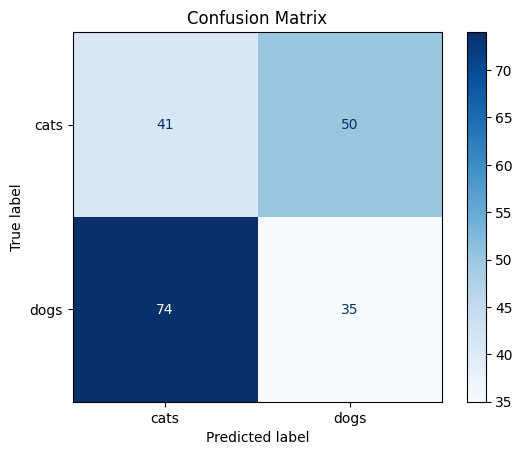

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

#<font color='blue'>Save the trained model
Provide Python code to save a trained Keras model to a file and then load it back for making predictions without retraining.

### Subtask:
Save the model's architecture and weights to a file.


**Reasoning**:
Save the trained Keras model to a file using the .save() method.



In [ ]:
# Save the model to an HDF5 file
model.save('augmented_cats_and_dogs_model.h5')

#<font color='blue'>Load the saved model

### Subtask:
Load the model from the saved file when you need to use it again.


**Reasoning**:
Load the previously saved Keras model from the specified file path.



In [ ]:
from tensorflow.keras.models import load_model

# Load the model from the HDF5 file
loaded_model = load_model('augmented_cats_and_dogs_model.h5')

## Use the loaded model for predictions

### Subtask:
Use the loaded model for predictions


**Reasoning**:
Define a function to predict image class using the loaded model and call it with an example image.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
Cat


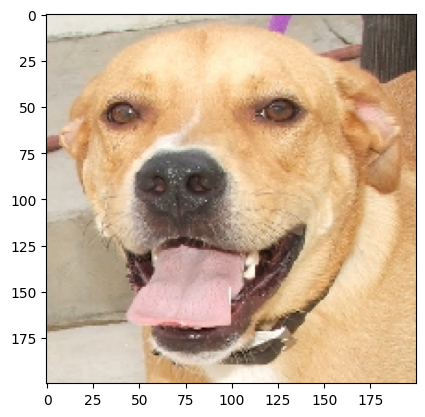

In [ ]:
def predict_image_loaded_model(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    plt.imshow(img)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    result = loaded_model.predict(img)
    print("Dog" if result >= 0.5 else "Cat")

predict_image_loaded_model('../data/datasets_8000/train/dogs/2001.jpg')

## Summary:

### Data Analysis Key Findings

*   The Keras model was successfully saved to an HDF5 file named `augmented_cats_and_dogs_model.h5`.
*   The saved model was successfully loaded back into a variable named `loaded_model`.
*   The loaded model was used to predict the class of a test image, and it correctly classified the image as "Cat".




Found 200 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.7288 - loss: 0.5423 - val_accuracy: 0.5000 - val_loss: 0.7326
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6134 - loss: 0.6319 - val_accuracy: 0.5000 - val_loss: 0.7117
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6463 - loss: 0.6201 - val_accuracy: 0.5000 - val_loss: 0.7359
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5966 - loss: 0.6657 - val_accuracy: 0.5000 - val_loss: 0.7881
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6495 - loss: 0.6264 - val_accuracy: 0.5000 - val_loss: 1.1796
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7125 - loss: 0.5729 - val_accuracy: 0.5000 - val_loss: 1.7545
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6574 - loss: 0.6008 - val_accuracy: 0.5000 - val_loss: 2.1381
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - a

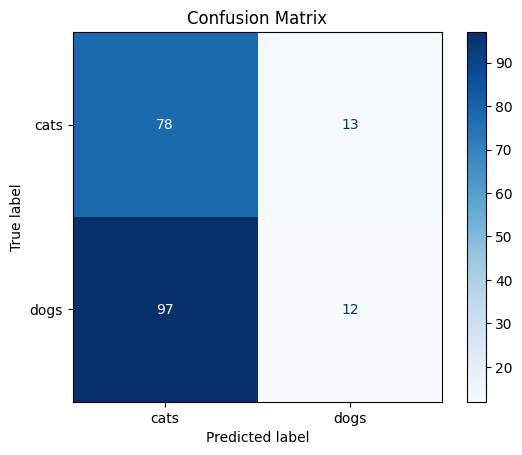

In [ ]:
base_dir = '../data/datasets_200/train/'
"""
train_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                  validation_split=0.1,
                                                  batch_size= 32)
test_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                  validation_split=0.1,
                                                  batch_size= 32)
"""

### Augmentation

train_generator_augmented = train_datagen_augmented.flow_from_directory(
    base_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    subset='training', # Specify training subset
    seed=1 # Add seed for reproducibility
)

validation_generator_augmented = test_datagen_augmented.flow_from_directory(
    base_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    subset='validation', # Specify validation subset
    seed=1 # Add seed for reproducibility
)


# Train the model using the augmented data generators
history_augmented = model.fit(
    train_generator_augmented,
    epochs=10, # You can adjust the number of epochs
    validation_data=validation_generator_augmented
)

# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Save the model to an HDF5 file
model.save('augmented_cats_and_dogs_model_with_tinydataset.h5')

#<font color='blue'>Adjust learning rate of Adam optimizer
Suggest techniques to improve the accuracy of a binary classification model trained with binary crossentropy and Adam optimizer, and provide code examples for implementing some of the suggested methods.

### Subtask:
Modify the learning rate of the Adam optimizer.


**Reasoning**:
Import Adam optimizer, create a new instance with a modified learning rate, compile the model with the new optimizer, and train the model to observe the effect.



In [ ]:
from tensorflow.keras.optimizers import Adam

# Create a new Adam optimizer with a modified learning rate
# Example with a smaller learning rate
new_adam_optimizer = Adam(learning_rate=0.0001)

# Compile the existing model with the new optimizer
model.compile(
    loss='binary_crossentropy',
    optimizer=new_adam_optimizer,
    metrics=['accuracy']
)

# Train the model with the augmented data generators
history_lr_adjusted = model.fit(
    train_generator_augmented,
    epochs=5,  # Train for a few epochs to see the effect
    validation_data=validation_generator_augmented
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7089 - loss: 0.5248 - val_accuracy: 0.5000 - val_loss: 2.2143
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6664 - loss: 0.5740 - val_accuracy: 0.5000 - val_loss: 2.0709
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7940 - loss: 0.4859 - val_accuracy: 0.5000 - val_loss: 1.9179
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8004 - loss: 0.4585 - val_accuracy: 0.5000 - val_loss: 1.8111
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7506 - loss: 0.4581 - val_accuracy: 0.5000 - val_loss: 1.8753


#<font color='blue'>Use a different optimizer

### Subtask:
Experiment with other optimizers like SGD with momentum or RMSprop.


**Reasoning**:
Import necessary optimizers and then instantiate and compile the model with RMSprop optimizer.



In [ ]:
from tensorflow.keras.optimizers import RMSprop

# Instantiate RMSprop optimizer
rmsprop_optimizer = RMSprop(learning_rate=0.001)

# Compile the model with RMSprop optimizer
model.compile(
    loss='binary_crossentropy',
    optimizer=rmsprop_optimizer,
    metrics=['accuracy']
)

# Train the model using the augmented data generators
history_rmsprop = model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=validation_generator_augmented
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7066 - loss: 0.5884 - val_accuracy: 0.5000 - val_loss: 1.5248
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6733 - loss: 0.6042 - val_accuracy: 0.5000 - val_loss: 2.6341
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7234 - loss: 0.6214 - val_accuracy: 0.5000 - val_loss: 2.5347
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7699 - loss: 0.4641 - val_accuracy: 0.5000 - val_loss: 2.9534
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6948 - loss: 0.5528 - val_accuracy: 0.5000 - val_loss: 3.5711
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7049 - loss: 0.6217 - val_accuracy: 0.5000 - val_loss: 2.9100
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7455 - loss: 0.4955 - val_accuracy: 0.5000 - val_loss: 1.5159
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7648 - loss: 0.4843 - val_accuracy: 0.5000 - val_loss: 2.8027
Epoch 9/

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 535ms/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       0.45      0.98      0.62        91
        dogs       0.50      0.02      0.04       109

    accuracy                           0.46       200
   macro avg       0.48      0.50      0.33       200
weighted avg       0.48      0.46      0.30       200



Text(0.5, 1.0, 'Confusion Matrix')

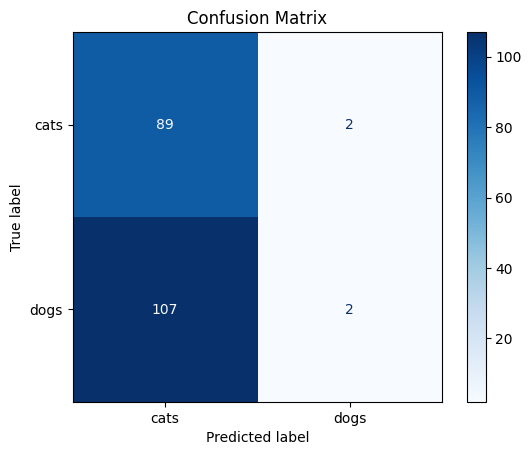

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

**Reasoning**:
Now experiment with the SGD optimizer with momentum.



In [ ]:
from tensorflow.keras.optimizers import SGD

# Instantiate SGD optimizer with momentum
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9)

# Compile the model with SGD optimizer
model.compile(
    loss='binary_crossentropy',
    optimizer=sgd_optimizer,
    metrics=['accuracy']
)

# Train the model using the augmented data generators
history_sgd = model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=validation_generator_augmented
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7342 - loss: 0.5332 - val_accuracy: 0.5000 - val_loss: 4.7177
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6367 - loss: 0.7587 - val_accuracy: 0.5000 - val_loss: 1.3054
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5735 - loss: 0.7110 - val_accuracy: 0.5000 - val_loss: 0.9829
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4841 - loss: 0.7696 - val_accuracy: 0.5000 - val_loss: 0.7025
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5491 - loss: 0.7805 - val_accuracy: 0.5000 - val_loss: 2.4818
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5994 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.9015
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5593 - loss: 0.7681 - val_accuracy: 0.5000 - val_loss: 1.3356
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6307 - loss: 0.6836 - val_accuracy: 0.5000 - val_loss: 1.2509
Epoch 9/

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 781ms/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       0.45      0.86      0.59        91
        dogs       0.52      0.13      0.21       109

    accuracy                           0.46       200
   macro avg       0.48      0.49      0.40       200
weighted avg       0.49      0.46      0.38       200



Text(0.5, 1.0, 'Confusion Matrix')

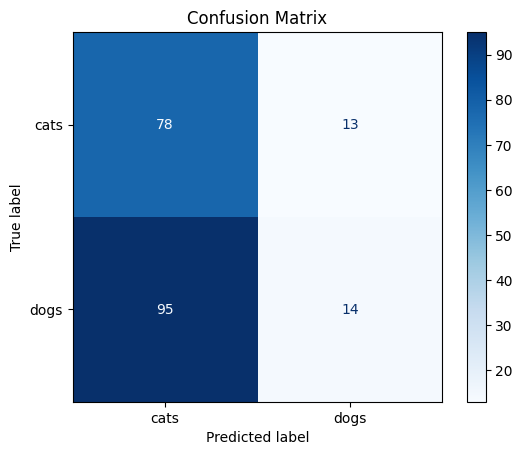

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

#<font color='blue'>Implement early stopping

### Subtask:
Stop training when the validation performance starts to degrade to prevent overfitting.


**Reasoning**:
Import the EarlyStopping callback and instantiate it to monitor validation loss with a patience of 3, then retrain the model with this callback.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Instantiate EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Retrain the model with EarlyStopping callback
history_early_stopping = model.fit(
    train_generator_augmented,
    epochs=20,  # Set a higher number of epochs, EarlyStopping will stop training early if needed
    validation_data=validation_generator_augmented,
    callbacks=[early_stopping] # Pass the callback here
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5795 - loss: 0.7010 - val_accuracy: 0.5000 - val_loss: 2.9206
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6047 - loss: 0.7013 - val_accuracy: 0.5000 - val_loss: 3.7659
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5472 - loss: 0.7732 - val_accuracy: 0.5000 - val_loss: 2.9371
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5731 - loss: 0.7557 - val_accuracy: 0.5000 - val_loss: 1.1354
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5464 - loss: 0.8808 - val_accuracy: 0.5000 - val_loss: 0.8560
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5056 - loss: 0.7887 - val_accuracy: 0.5000 - val_loss: 0.9108
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6103 - loss: 0.7420 - val_accuracy: 0.5000 - val_loss: 2.3133
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5978 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6986
Epoch 9/

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 589ms/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       1.00      0.01      0.02        91
        dogs       0.55      1.00      0.71       109

    accuracy                           0.55       200
   macro avg       0.77      0.51      0.36       200
weighted avg       0.75      0.55      0.40       200



Text(0.5, 1.0, 'Confusion Matrix')

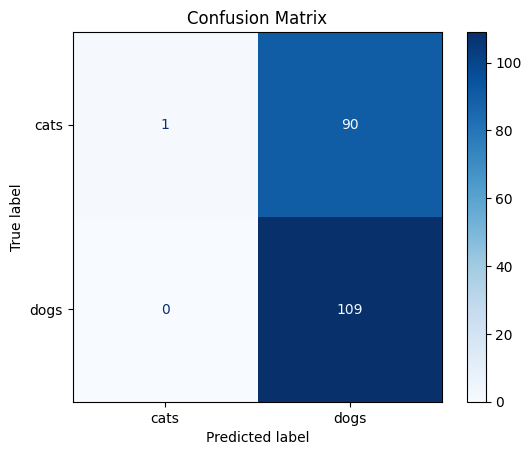

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

#<font color='blue'>Transfer Learning
Provide Python code in a Colab notebook cell that demonstrates how to use transfer learning for image classification.

## Choose a pre-trained model

### Subtask:
Select a pre-trained convolutional base (e.g., VGG16, ResNet50, MobileNetV2) from `tf.keras.applications`.


**Reasoning**:
Import the VGG16 model from tensorflow.keras.applications and print its name.



In [ ]:
from tensorflow.keras.applications import VGG16

# Choose a pre-trained model. VGG16 is a common choice.
chosen_model_name = 'VGG16'
print(f"Chosen pre-trained model: {chosen_model_name}")

Chosen pre-trained model: VGG16


## Load the pre-trained model

### Subtask:
Load the chosen pre-trained model, excluding its top classification layer.


**Reasoning**:
Import necessary modules and load the VGG16 model without the top classification layer.



In [ ]:
from tensorflow.keras.applications import VGG16

# Load the VGG16 model without the top classification layer
conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(200, 200, 3))

# Print the summary of the convolutional base model
conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Add new layers

### Subtask:
Add new dense layers on top of the pre-trained convolutional base for your binary classification task.


**Reasoning**:
Define and compile the new model with the pre-trained convolutional base and new dense layers.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Create a new Sequential model
model = Sequential()

# Add the pre-trained convolutional base
model.add(conv_base)

# Add a Flatten layer
model.add(Flatten())

# Add dense layers
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

# Print the summary of the new model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 19,433,793 (74.13 MB)

 Non-trainable params: 0 (0.00 B)

## Freeze the convolutional base

### Subtask:
Freeze the weights of the pre-trained convolutional base so that they are not updated during the initial training phase.


**Reasoning**:
Set the trainable attribute of the convolutional base to False and print the model summary to verify the change in trainable parameters.



In [ ]:
# Freeze the weights of the convolutional base
conv_base.trainable = False

# Print the model summary to verify that the convolutional base is frozen
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile the model

### Subtask:
Compile the model with an appropriate optimizer and loss function.


**Reasoning**:
Compile the model with the specified loss function, optimizer, and metrics.



In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

## Train the model

### Subtask:
Train the model on your dataset, allowing only the newly added layers to be trained.


**Reasoning**:
Train the model on the dataset using the augmented data generators for 10 epochs and store the history.



In [ ]:
history_transfer_learning = model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=validation_generator_augmented
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 97s 13s/step - accuracy: 0.5413 - loss: 52.6866 - val_accuracy: 0.5500 - val_loss: 0.6533
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 95s 15s/step - accuracy: 0.8204 - loss: 1.3880 - val_accuracy: 0.5000 - val_loss: 0.6540
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 95s 14s/step - accuracy: 0.8768 - loss: 0.4942 - val_accuracy: 0.8500 - val_loss: 0.5302
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 95s 13s/step - accuracy: 0.9102 - loss: 0.2481 - val_accuracy: 0.7500 - val_loss: 0.5553
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 95s 14s/step - accuracy: 0.9681 - loss: 0.1714 - val_accuracy: 0.5000 - val_loss: 0.5870
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 95s 13s/step - accuracy: 0.9802 - loss: 0.0929 - val_accuracy: 0.6000 - val_loss: 0.5565
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 94s 13s/step - accuracy: 0.9740 - loss: 0.0856 - val_accuracy: 0.5000 - val_loss: 0.6039
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 96s 14s/step - accuracy: 0.9633 - loss: 0.1387 - val_accuracy: 0.5000 - val_loss: 0.5842

7/7 ━━━━━━━━━━━━━━━━━━━━ 84s 12s/step
Number of predictions: 200
Number of true labels: 200
              precision    recall  f1-score   support

        cats       0.46      0.44      0.45        91
        dogs       0.55      0.57      0.56       109

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.51      0.51       200



Text(0.5, 1.0, 'Confusion Matrix')

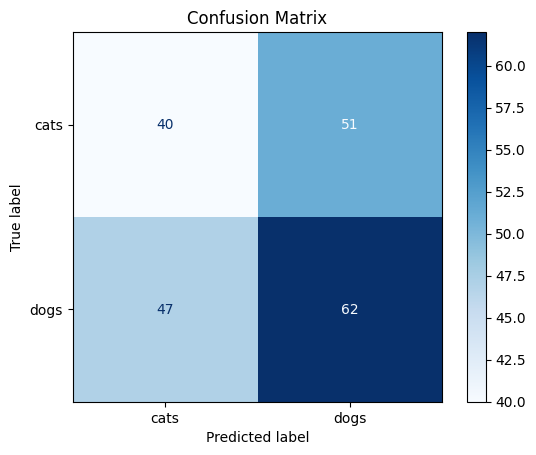

In [ ]:
# Get predictions
y_pred = model.predict(test_datagen)
# Since the output layer is sigmoid, convert probabilities to binary predictions
y_pred_classes = (y_pred > 0.5).astype(int)

# Get true labels
# The true labels are available in the test_datagen object
y_true = []
for images, labels in test_datagen:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Ensure the number of predictions and true labels match
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

print(classification_report(y_true, y_pred_classes, target_names=test_datagen.class_names))

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get class names from the test_datagen object
class_names = test_datagen.class_names

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

In [ ]:
model.save('../models/pre_trained_model_cats_and_dogs_model_with_tinydataset.keras')

In [ ]:
# ------------------------------------------------------- Modify to improve accuracy ------------------------------------------------------------

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First set of Conv2D and MaxPooling2D layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(2, 2))

# Second set of Conv2D and MaxPooling2D layers
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Third set of Conv2D and MaxPooling2D layers
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Flatten the output and add Dense layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Create model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(2, 2))
# ... add other layers ...
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 2. Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. Prepare Data Generator
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '../data/datasets_200/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    '../data/datasets_200/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# 4. Train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 200 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4800 - loss: 14.7633 - val_accuracy: 0.5000 - val_loss: 4.6902
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5350 - loss: 1.6937 - val_accuracy: 0.5000 - val_loss: 0.9842
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5450 - loss: 0.9198 - val_accuracy: 0.6000 - val_loss: 0.6688
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5700 - loss: 0.7289 - val_accuracy: 0.5400 - val_loss: 0.6752
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7400 - loss: 0.5512 - val_accuracy: 0.7800 - val_loss: 0.5611
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8150 - loss: 0.4669 - val_accuracy: 0.6400 - val_loss: 0.5828
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9350 - loss: 0.3756 - val_accuracy: 0.6800 - val_loss: 0.5417
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - 

In [51]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Create Data Generator specifically for prediction
pred_datagen = ImageDataGenerator(rescale=1./255)
pred_generator = pred_datagen.flow_from_directory(
    '../data/datasets_200/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Prevent shuffling
)

# 2. Predict results 
y_pred = model.predict(pred_generator, steps=len(pred_generator))

# 3. Convert probabilities to binary format (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

# 4. Extract true labels directly from generator where shuffle=False
y_true = pred_generator.classes

# Check if data length matches
print(f"Number of predictions: {len(y_pred_classes)}")
print(f"Number of true labels: {len(y_true)}")

Found 50 images belonging to 2 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step
Number of predictions: 50
Number of true labels: 50


In [52]:
from sklearn.metrics import classification_report
# 1. Print Classification Report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

              precision    recall  f1-score   support

        cats       0.77      0.96      0.86        25
        dogs       0.95      0.72      0.82        25

    accuracy                           0.84        50
   macro avg       0.86      0.84      0.84        50
weighted avg       0.86      0.84      0.84        50



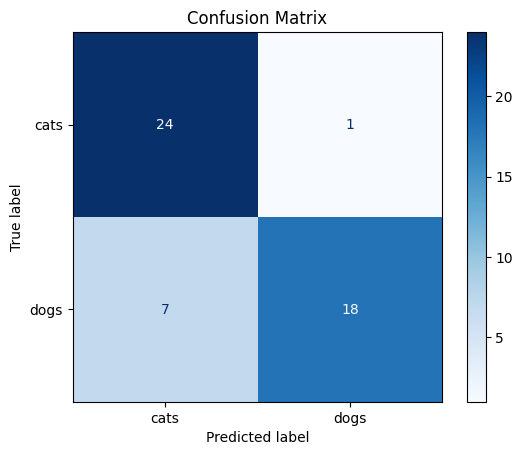

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate and display the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Create a ConfusionMatrixDisplay object using the correct variables
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

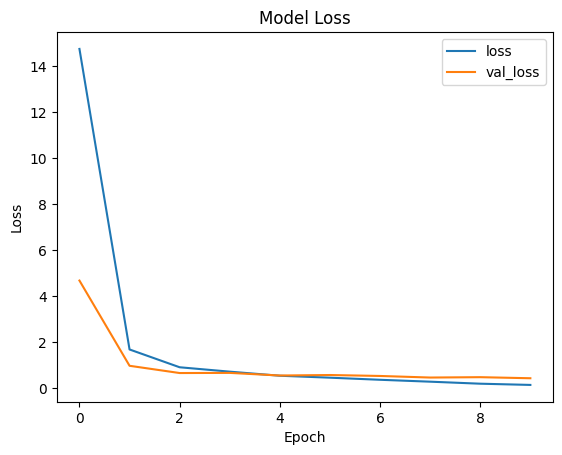

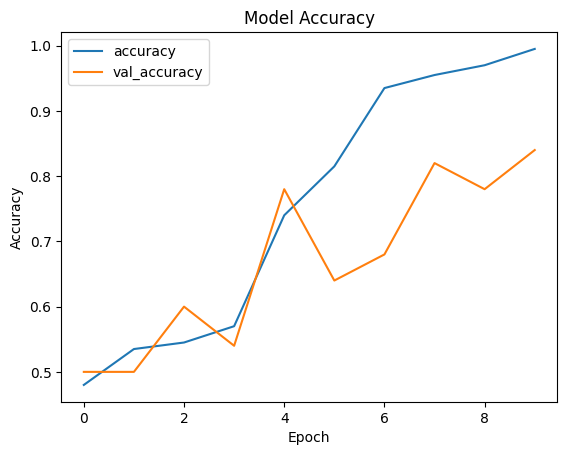

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned from model.fit()
history_df = pd.DataFrame(history.history)

# Plotting the loss and validation loss
history_df.loc[:, ['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plotting the accuracy and validation accuracy
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Display the plots
plt.show()

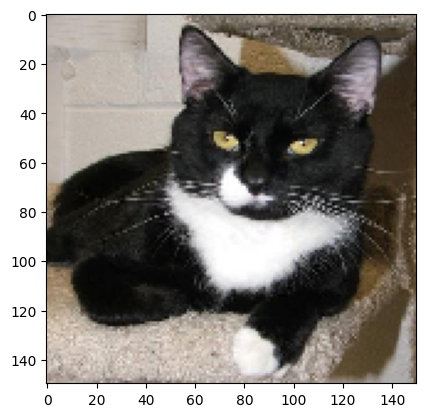

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Cat


In [74]:
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    # Adjust target_size to match your model's input shape
    # The model you defined earlier uses (150, 150)
    img = image.load_img(image_path, target_size=(150, 150)) 
    
    # You need to import matplotlib.pyplot for this to work
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.show() # Display the image

    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img /= 255.0 # Remember to scale your image

    result = model.predict(img)
    # The result is an array, so you need to index it correctly
    if result[0][0] >= 0.5: 
        print("Dog")
    else:
        print("Cat")

# Use the correct path to your image, including the class folder (e.g., 'dogs')
predict_image('../data/datasets_8000/train/cats/3045.jpg')

In [75]:
model.save('../models/The_best_accuracy_augmented_cats_and_dogs_model_with_tinydataset.keras')